In [17]:
from sklearn import datasets
from sklearn.cluster import KMeans, DBSCAN
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score, adjusted_mutual_info_score
from scipy.cluster.hierarchy import dendrogram,linkage,fcluster

In [18]:
iris = datasets.load_iris()

In [19]:
X = iris.data

### K-средних

In [20]:
k_means = KMeans(n_clusters = 3, random_state = 42, n_init = 10).fit(X)

In [21]:
k_means.cluster_centers_

array([[5.9016129 , 2.7483871 , 4.39354839, 1.43387097],
       [5.006     , 3.428     , 1.462     , 0.246     ],
       [6.85      , 3.07368421, 5.74210526, 2.07105263]])

In [22]:
k_means.labels_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 0, 0, 2, 2, 2, 2, 0, 2, 0, 2, 0, 2, 2, 0, 0, 2, 2, 2, 2,
       2, 0, 2, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 2, 0, 2, 2, 0], dtype=int32)

In [23]:
silhouette_score(X,k_means.labels_)

0.5528190123564095

In [24]:
y = iris.target

In [25]:
adjusted_mutual_info_score(y, k_means.labels_, average_method = 'arithmetic')

0.7551191675800485

### DBSCAN

In [26]:
db = DBSCAN(eps = 0.6, min_samples = 10).fit(X)
db

,eps,0.6
,min_samples,10
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


In [27]:
silhouette_score(X, db.labels_)

0.5421203936716451

In [28]:
adjusted_mutual_info_score(y, db.labels_, average_method = 'arithmetic')

0.6162312414524308

# Кластерный анализ

In [29]:
df = pd.read_csv('beverage_r.csv', sep = ';', index_col = 'numb.obs')
df.head()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
numb.obs,,,,,,,,
1,1,0,0,0,1,1,0,1
2,1,0,0,0,1,0,0,0
3,1,0,0,0,1,0,0,0
4,0,1,0,1,0,0,1,0
5,1,0,0,0,1,0,0,0


In [30]:
df.shape

(34, 8)

In [31]:
link = linkage(df,'ward', 'euclidean')

In [32]:
link[:5]

array([[ 5., 10.,  0.,  2.],
       [ 1.,  2.,  0.,  2.],
       [ 4., 35.,  0.,  3.],
       [ 3., 22.,  0.,  2.],
       [20., 36.,  0.,  4.]])

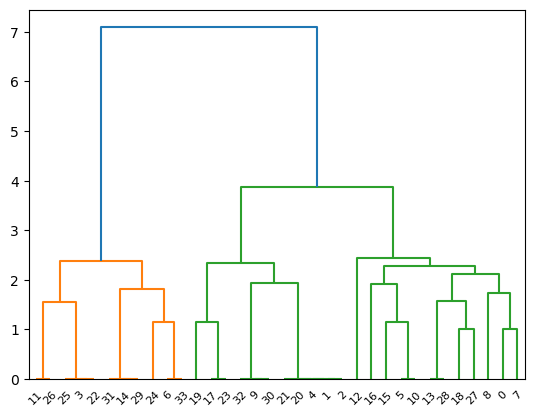

In [34]:
dendrogram(link);

In [35]:
df['cluster'] = fcluster(link,2, criterion = 'maxclust')
df.head()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP,cluster
numb.obs,,,,,,,,,
1,1,0,0,0,1,1,0,1,2
2,1,0,0,0,1,0,0,0,2
3,1,0,0,0,1,0,0,0,2
4,0,1,0,1,0,0,1,0,1
5,1,0,0,0,1,0,0,0,2


In [36]:
df.groupby('cluster').size()

cluster
1    11
2    23
dtype: int64

In [37]:
df['cluster'] = fcluster(link,3, criterion = 'maxclust')
df.groupby('cluster').size()

cluster
1    11
2    11
3    12
dtype: int64

In [42]:
df = pd.read_csv('beverage_r.csv', sep = ';', index_col = 'numb.obs')
df.head()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP
numb.obs,,,,,,,,
1,1,0,0,0,1,1,0,1
2,1,0,0,0,1,0,0,0
3,1,0,0,0,1,0,0,0
4,0,1,0,1,0,0,1,0
5,1,0,0,0,1,0,0,0


In [39]:
model = KMeans(n_clusters = 3, random_state = 42).fit(df)
model

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [40]:
df['cluster'] = model.labels_
df.head()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP,cluster
numb.obs,,,,,,,,,
1,1,0,0,0,1,1,0,1,1
2,1,0,0,0,1,0,0,0,1
3,1,0,0,0,1,0,0,0,1
4,0,1,0,1,0,0,1,0,2
5,1,0,0,0,1,0,0,0,1


In [41]:
silhouette_score (df, model.labels_)

0.43393690639017435

In [43]:
model = KMeans(n_clusters = 2, random_state = 42).fit(df)
model

,n_clusters,2
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


In [44]:
df['cluster'] = model.labels_
df.head()

,COKE,D_COKE,D_PEPSI,D_7UP,PEPSI,SPRITE,TAB,SEVENUP,cluster
numb.obs,,,,,,,,,
1,1,0,0,0,1,1,0,1,1
2,1,0,0,0,1,0,0,0,1
3,1,0,0,0,1,0,0,0,1
4,0,1,0,1,0,0,1,0,0
5,1,0,0,0,1,0,0,0,1


In [45]:
silhouette_score (df, model.labels_)

0.4576042877856255

In [46]:
x_new = [[1,1,1,1,1,1,1,1],[0,0,0,0,0,0,0,0]]

In [48]:
model.predict(x_new)

/opt/conda/envs/anaconda-2025.12-py312/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


array([0, 1], dtype=int32)